In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

sns.set(style="whitegrid")
%matplotlib inline

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

pl = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
dim_company = pd.read_sql("SELECT * FROM dim_company", engine)

In [2]:
pl_y = pl[~pl["year_label"].str.contains("TTM", case=False, na=False)].copy()

In [3]:
trend_rows = []

for sym, g in pl_y.groupby("symbol"):
    g2 = g.sort_values("year_label").tail(5)
    if len(g2) < 2:
        continue
    
    x = np.arange(len(g2))
    y = g2["sales"].astype(float).values
    
    slope, intercept = np.polyfit(x, y, 1)
    
    if slope > 0:
        trend = "UP"
    elif slope < 0:
        trend = "DOWN"
    else:
        trend = "FLAT"
    
    trend_rows.append({
        "symbol": sym,
        "slope": slope,
        "trend_label": trend
    })

trend_df = pd.DataFrame(trend_rows)
trend_df.head()

,symbol,slope,trend_label
0,ABB,455.1,UP
1,ADANIENSOL,1374.9,UP
2,ADANIENT,19403.9,UP
3,ADANIGREEN,1799.4,UP
4,ADANIPORTS,2504.3,UP


In [4]:
trend_df = trend_df.merge(
    dim_company[["symbol", "company_name", "sector"]],
    on="symbol",
    how="left"
)

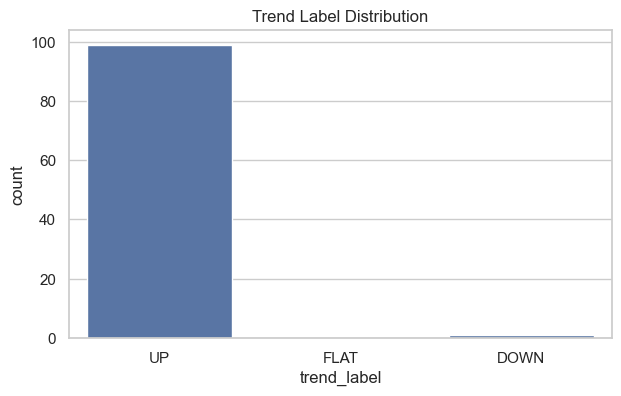

In [5]:
plt.figure(figsize=(7,4))
sns.countplot(data=trend_df, x="trend_label", order=["UP","FLAT","DOWN"])
plt.title("Trend Label Distribution")
plt.show()

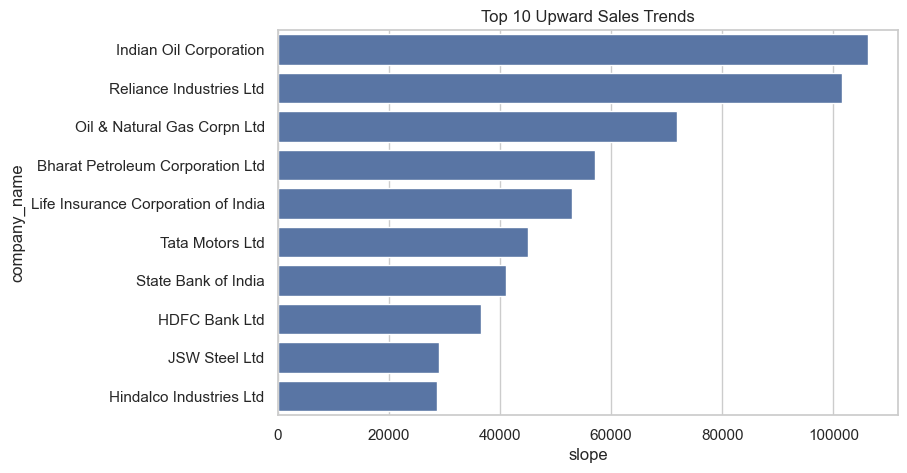

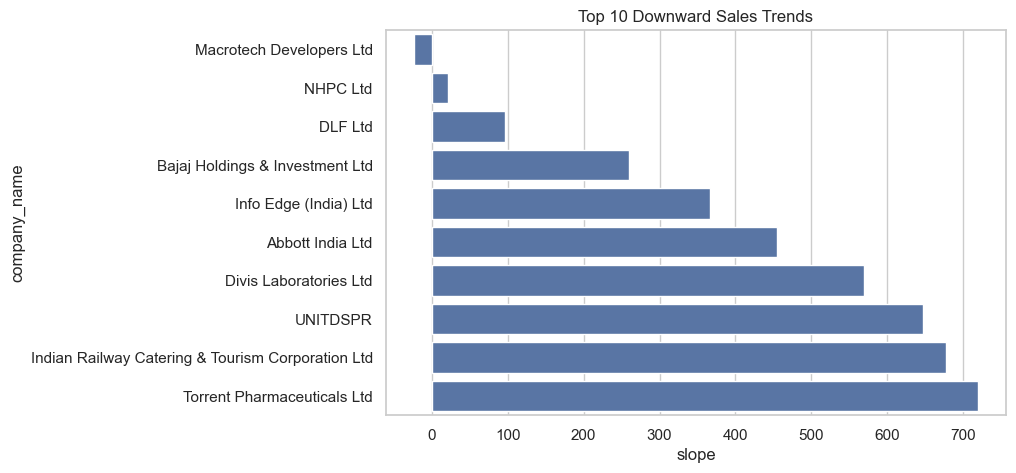

In [6]:
top_up = trend_df.nlargest(10, "slope")
top_down = trend_df.nsmallest(10, "slope")

plt.figure(figsize=(8,5))
sns.barplot(data=top_up, x="slope", y="company_name")
plt.title("Top 10 Upward Sales Trends")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=top_down, x="slope", y="company_name")
plt.title("Top 10 Downward Sales Trends")
plt.show()

In [7]:
top20_symbols = (
    pl_y.groupby("symbol")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

In [8]:
forecast_rows = []

for sym in top20_symbols:
    g = pl_y[pl_y["symbol"] == sym].sort_values("year_label").tail(5)
    if len(g) < 2:
        continue
        
    x = np.arange(len(g))
    y = g["sales"].astype(float).values
    
    slope, intercept = np.polyfit(x, y, 1)
    next_x = len(g)
    forecast = slope * next_x + intercept
    
    forecast_rows.append({
        "symbol": sym,
        "forecast_sales_next_year": forecast,
        "slope": slope
    })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df = forecast_df.merge(
    dim_company[["symbol","company_name","sector"]],
    on="symbol", how="left"
)
forecast_df.head()

,symbol,forecast_sales_next_year,slope,company_name,sector
0,RELIANCE,1011063.1,101481.3,Reliance Industries Ltd,Other
1,IOC,929923.6,106298.4,Indian Oil Corporation,Energy
2,LICI,893499.4,52956.0,Life Insurance Corporation of India,Other
3,ONGC,698435.4,71777.8,Oil & Natural Gas Corpn Ltd,Energy
4,BPCL,527572.2,57003.8,Bharat Petroleum Corporation Ltd,Energy


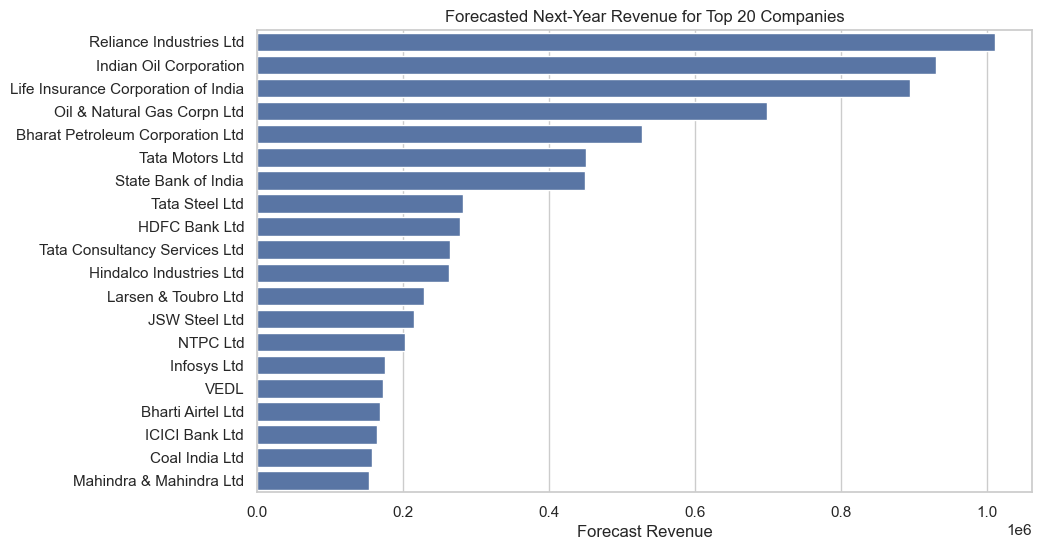

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=forecast_df.sort_values("forecast_sales_next_year", ascending=False),
            x="forecast_sales_next_year", y="company_name")
plt.title("Forecasted Next-Year Revenue for Top 20 Companies")
plt.xlabel("Forecast Revenue")
plt.ylabel("")
plt.show()

In [10]:
trend_out = "../data/clean/trend_labels.csv"
forecast_out = "../data/clean/revenue_forecasts.csv"

trend_df.to_csv(trend_out, index=False)
forecast_df.to_csv(forecast_out, index=False)

trend_out, forecast_out

('../data/clean/trend_labels.csv', '../data/clean/revenue_forecasts.csv')